# MiniGPT — Testing / Generation

In [5]:
from src.config import Config
from src.model import MiniGPT
from src.data import CharTokenizer, prepare_data
from src.utils import load_checkpoint, perplexity, generate, plot_embedding_pca
from src.train import estimate_loss
import torch.nn as nn
from pathlib import Path

config = Config()
device = config.device
print("Device:", device)

PROJECT_ROOT = Path("./")

Device: cuda


In [6]:
checkpoint_path = PROJECT_ROOT / "models" / "mini_gpt_best.pth"

model, checkpoint = load_checkpoint(
    str(checkpoint_path),
    MiniGPT,
    device
)

checkpoint_config = checkpoint["config"]
tokenizer = CharTokenizer.from_state_dict(checkpoint["tokenizer"])

print("Checkpoint loaded successfully.")
print("Training iteration:", checkpoint["iteration"])
print("Best validation loss:", checkpoint["best_val_loss"])
print("Vocabulary size:", tokenizer.vocab_size)

Checkpoint loaded successfully.
Training iteration: 9750
Best validation loss: 1.6996960639953613
Vocabulary size: 29


In [7]:
_, _, train_data, val_data = prepare_data(
    path=str(PROJECT_ROOT / checkpoint_config["data_path"]),
    fraction=checkpoint_config["data_fraction"],
    train_split=checkpoint_config["train_split"]
)

loss_fn = nn.CrossEntropyLoss()

losses = estimate_loss(
    model,
    train_data,
    val_data,
    loss_fn,
    checkpoint_config["batch_size"],
    checkpoint_config["block_size"],
    device,
    checkpoint_config["eval_iters"]
)

print(f"Train Loss: {losses['train']:.4f}")
print(f"Val Loss  : {losses['val']:.4f}")
print(f"Train Perplexity: {perplexity(losses['train']):.2f}")
print(f"Val Perplexity  : {perplexity(losses['val']):.2f}")

Original length: 111539
Cleaned length: 106823
Vocabulary size: 29
['\n', ' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Train characters: 96140
Validation characters: 10683
Train Loss: 1.5752
Val Loss  : 1.6993
Train Perplexity: 4.83
Val Perplexity  : 5.47


In [8]:
prompt = "The night was quiet, and the wind carried"

print(generate(
    model=model,
    prompt=prompt,
    tokenizer=tokenizer,
    block_size=checkpoint_config["block_size"],
    device=device,
    max_new_tokens=400,
    temperature=1.0
))

the night was quiet and the wind carried
and fiend veremrs corical bring too commine held all
onet of goodli sjeaw smon
you maday an
your in the sait than how
belore shou his liglr doch oor the my.
are men word fiex romorrpaitin loy one shoulne hear by alone froolanus
to and preve
oumst lets proweelip.
qenougrys swere them boward honours.
but shorbie do kneiries
isle chart usjeed
the beyll yer that who hower down boarte
of flusme at leu


In [9]:
print("Conservative")
print(generate(
    model, prompt, tokenizer,
    checkpoint_config["block_size"], device,
    400, temperature=0.5
))

print("\nMore Random")
print(generate(
    model, prompt, tokenizer,
    checkpoint_config["block_size"], device,
    400, temperature=1.5
))

print("\nTop-K Sampling")
print(generate(
    model, prompt, tokenizer,
    checkpoint_config["block_size"], device,
    400, temperature=0.8, top_k=10
))

Conservative
the night was quiet and the wind carried me the phe he should the shall and ming and the the receive and the people
the such and the come you their against of east the come and you be and the most my heart
and they the which he she have the sour and bring heart you are the would with forst a a with you she dour
come the now at all the people
of the shall see and you say man in not heart sore him you of instought with adn the your had th

More Random
the night was quiet and the wind carried qeaudce id lo.
twars harnnw ibotied hyse. olle ink so.
see genersy anhim
ukxiigam aestifes ever
ome wins faters
a swow stachintabrd wwy to laying.
 herea
yow xl.f w

both for
iubweuntljnh attsous
shalert
no
marmd tplhims ofbek he
they wheellohainng
what idrigh makt iscloui eyef then tongorrausilby in ontiegowin wefecalinzbdfice buey xrinfabity frlyei fies the hat thop lohiw alptes
heur og at mjrw

Top-K Sampling
the night was quiet and the wind carried marcius
why honours to they home th

Embedding shape: (29, 160)
PCA shape: (29, 2)
Explained variance: [0.10657068 0.09262349]
Total explained variance: 19.92%


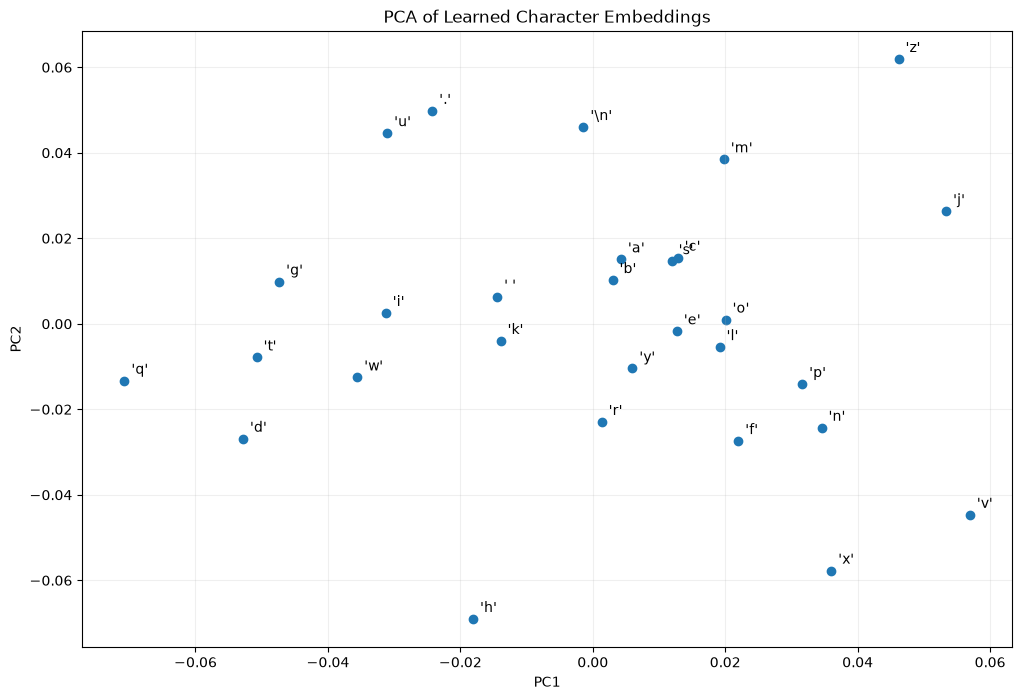

In [11]:
plot_embedding_pca(model=model, tokenizer=tokenizer)